# Predicción de vida útil remanente (RUL) de un cojinete

Este notebook construye un modelo de *Remaining Useful Life* (RUL) para estimar cuántos ciclos de operación le quedan a un cojinete antes de llegar a una condición de falla. El ejemplo usa datos sintéticos de sensores, de modo que puede ejecutarse sin descargar archivos externos y puede reemplazarse después por datos reales.

## 1. Contexto del problema

Imaginemos una máquina rotativa de una línea de producción. Uno de sus cojinetes soporta el eje principal y está instrumentado con sensores de vibración, temperatura, carga y ruido acústico. Con el uso, el cojinete se degrada: aumenta la vibración, sube la temperatura y aparecen cambios en la señal acústica.

El problema de negocio es sencillo de expresar: una falla inesperada puede detener la producción, dañar otros componentes y elevar el costo de mantenimiento. Sin embargo, cambiar el cojinete demasiado pronto también desperdicia vida útil.

La pregunta de I+D es: **dado el historial de sensores hasta este momento, ¿cuántos ciclos de operación faltan aproximadamente para que el cojinete llegue al final de su vida útil?**

## 2. Principios de la técnica RUL

RUL es una tarea de **regresión supervisada** dentro del mantenimiento predictivo. Se siguen estos principios:

1. Cada componente se observa a lo largo del tiempo, desde una condición sana hasta la falla.
2. Para cada instante se calcula una etiqueta: `RUL = ciclo_de_falla - ciclo_actual`.
3. Se separan componentes completos para entrenamiento y prueba; nunca se deben mezclar ciclos del mismo componente en ambos grupos, porque eso produciría fuga de información.
4. El modelo aprende la relación entre señales de condición y vida restante.
5. La predicción debe interpretarse junto con el contexto de mantenimiento, no como una fecha exacta de falla.

En un proyecto real también serían importantes la calidad de los sensores, la frecuencia de muestreo, la definición de falla, la censura de unidades que no han fallado y el costo de los falsos avisos.

## Explicación ampliada de RUL, en lenguaje sencillo

RUL significa **Remaining Useful Life**, que podemos traducir como **vida útil remanente**. Es una estimación de cuánto tiempo, cuántos ciclos o cuántas horas puede seguir funcionando un componente antes de llegar a una condición de falla definida.

### ¿Qué problema resuelve?

En mantenimiento tradicional se pueden presentar dos errores:

- **Mantenimiento demasiado tarde:** el cojinete falla sin aviso, se detiene la máquina y puede dañar otros componentes.
- **Mantenimiento demasiado pronto:** se cambia un cojinete que todavía tenía vida disponible, generando un costo innecesario.

El objetivo de RUL es encontrar un punto intermedio. El modelo observa señales como vibración y temperatura, reconoce cómo suelen cambiar durante el desgaste y estima cuánto falta para alcanzar el final de vida.

### ¿Cómo se construye la etiqueta?

Para cada componente se conoce, al menos durante el entrenamiento, el ciclo en el que ocurrió la falla. Entonces se calcula:

```text
RUL = ciclo de falla - ciclo actual
```

Por ejemplo, si un cojinete falló en el ciclo 300:

- en el ciclo 50, su RUL es 250;
- en el ciclo 200, su RUL es 100;
- en el ciclo 299, su RUL es 1;
- en el ciclo 300, su RUL es 0.

Por eso RUL es una variable que normalmente disminuye con el tiempo.

### ¿Qué aprende el modelo?

El modelo no aprende una regla fija como “cada cojinete dura exactamente 300 ciclos”. Aprende patrones entre las mediciones y el desgaste. Por ejemplo, puede encontrar que una combinación de vibración alta, temperatura elevada y aumento de variabilidad suele aparecer cuando queda poca vida.

### Principios que se deben respetar

1. **Orden temporal:** las observaciones deben conservar el orden de los ciclos.
2. **Identidad del componente:** cada cojinete debe tener un identificador para seguir su historia.
3. **Separación por componente:** todos los ciclos de un cojinete deben quedar en entrenamiento o en prueba, pero no repartidos entre ambos grupos.
4. **Evitar fuga de información:** una variable calculada en el ciclo actual no debe utilizar datos futuros.
5. **Definición clara de falla:** hay que establecer qué significa “fin de vida”: vibración límite, temperatura límite, daño confirmado o paro de la máquina.
6. **Métrica útil para mantenimiento:** el error debe expresarse en una unidad comprensible, como ciclos u horas.
7. **Uso como apoyo a la decisión:** una predicción de RUL orienta la inspección; no reemplaza los límites de seguridad ni el criterio de ingeniería.

### RUL como problema de regresión

Este notebook trata RUL como una regresión porque la respuesta es un número continuo: 0, 1, 2, 3 ciclos restantes, etc. No se está preguntando solamente “¿fallará o no fallará?”, sino “¿cuánto falta aproximadamente?”.

En un proyecto real pueden existir componentes que todavía no han fallado cuando termina el registro. Esos casos se conocen como datos censurados y requieren técnicas adicionales. El ejemplo actual supone que las unidades simuladas tienen una vida completa observada.

## 3. Preparación del entorno

La celda siguiente importa las bibliotecas principales. Colab normalmente ya las incluye; solo se propone una instalación mínima si alguna importación falla. `pandas` organiza los datos, `numpy` realiza cálculos numéricos, `matplotlib` y `seaborn` generan visualizaciones y `scikit-learn` proporciona el modelo y las métricas.

### Antes de ejecutar: preparar las bibliotecas

Este bloque prepara las herramientas que usaremos. Una biblioteca es un conjunto de funciones ya programadas para resolver tareas comunes.

- `numpy` ayuda con arreglos y cálculos numéricos.
- `pandas` organiza la información en tablas.
- `matplotlib` y `seaborn` crean gráficas.
- `scikit-learn` contiene los modelos, la separación de datos y las métricas.

La semilla `SEED = 42` hace que los números aleatorios sean repetibles. Esto significa que, al volver a ejecutar el notebook, se obtiene el mismo ejemplo y los resultados se pueden comparar.

In [ ]:
# En Google Colab, ejecuta esta celda una vez por sesión.
# Google Colab normalmente ya incluye estas bibliotecas.
# Si la importación falla, descomenta y ejecuta una vez:
# %pip install -q scikit-learn seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
print("Bibliotecas listas")

Bibliotecas listas


## 4. Generación de un conjunto de datos sintético

Como no dependemos de un archivo externo, simularemos 80 cojinetes. Cada uno tiene una vida diferente. Para cada ciclo generamos sensores que empiezan cerca de una condición normal y se deterioran gradualmente, con ruido aleatorio.

La simulación no pretende representar exactamente una máquina real; su propósito es enseñar el flujo completo. En un proyecto industrial, esta celda se sustituiría por la lectura de archivos, una base de datos o un sistema historiador.

### ¿Por qué usamos datos sintéticos?

Los datos sintéticos son datos creados artificialmente para imitar una situación real. Aquí nos permiten practicar sin depender de información industrial confidencial ni de un archivo externo. Es parecido a entrenar con un simulador antes de trabajar con una máquina real.

Sirven para entender el procedimiento, pero no sustituyen la validación con mediciones reales. En un proyecto industrial, esta parte se reemplazaría con datos históricos de sensores y registros de mantenimiento.


### Antes de ejecutar: crear datos de sensores

Esta función simula la operación de varios cojinetes. En cada vuelta del ciclo se generan cuatro señales. El punto importante es que el deterioro no ocurre de golpe: comienza pequeño y aumenta conforme se acerca la falla.

La lista `filas` acumula una observación por componente y por ciclo. Después se convierte en un `DataFrame`, que es una tabla de pandas.

Dentro del ciclo:

- `vida_total` define cuántos ciclos durará esa unidad.
- `progreso` indica qué proporción de su vida ha consumido.
- `desgaste` representa el deterioro acumulado.
- Las señales se calculan agregando ruido para imitar mediciones reales.
- `rul = vida_total - ciclo` crea la respuesta que el modelo aprenderá.

El ruido es intencional: si las señales fueran perfectas, el ejemplo sería poco parecido a un problema de sensores real.

In [ ]:
def generar_datos_rul(n_unidades=80, ciclo_min=180, ciclo_max=360, seed=42):
    rng = np.random.default_rng(seed)
    filas = []

    for unidad in range(1, n_unidades + 1):
        vida_total = int(rng.integers(ciclo_min, ciclo_max + 1))
        severidad = rng.uniform(0.85, 1.20)
        ciclos = np.arange(1, vida_total + 1)
        progreso = ciclos / vida_total

        # Degradación no lineal: lenta al principio y acelerada al final.
        desgaste = progreso ** 2.2 * severidad
        vibracion = 1.0 + 5.2 * desgaste + rng.normal(0, 0.16, len(ciclos))
        temperatura = 42.0 + 23.0 * desgaste + rng.normal(0, 0.60, len(ciclos))
        carga = 60.0 + 3.0 * np.sin(ciclos / 18) + rng.normal(0, 1.8, len(ciclos))
        ruido = 28.0 + 10.0 * (progreso ** 1.7) * severidad + rng.normal(0, 0.35, len(ciclos))

        for ciclo, vib, temp, load, acoustic in zip(ciclos, vibracion, temperatura, carga, ruido):
            filas.append({
                "unidad": unidad,
                "ciclo": ciclo,
                "vibracion_rms": vib,
                "temperatura_c": temp,
                "carga_pct": load,
                "ruido_acustico_db": acoustic,
                "rul": vida_total - ciclo
            })

    return pd.DataFrame(filas)

datos = generar_datos_rul()
print(f"Filas: {len(datos):,}")
print(f"Unidades: {datos['unidad'].nunique()}")
datos.head()

Filas: 21,202
Unidades: 80


,unidad,ciclo,vibracion_rms,temperatura_c,carga_pct,ruido_acustico_db,rul
0,1,1,1.120119,41.997136,61.430097,27.573442,195
1,1,2,1.150708,41.902895,60.581482,28.091298,194
2,1,3,0.688364,42.204889,61.865928,28.645693,193
3,1,4,0.792649,42.848903,61.073774,27.435319,192
4,1,5,1.022085,42.061563,61.776774,27.571258,191


**¿Qué significa la etiqueta `rul`?**

Si una unidad falla en el ciclo 250 y estamos observando el ciclo 200, su RUL es 50 ciclos. La etiqueta disminuye con el tiempo y llega a cero en el último ciclo registrado.

### Ejemplo sencillo de la etiqueta RUL

La RUL se parece al tiempo restante de una batería. Si una batería puede durar 10 horas y ya han pasado 3, quedan aproximadamente 7 horas. Aquí usamos ciclos en lugar de horas. Si la falla ocurre en el ciclo 300, en el ciclo 200 la RUL es 100.


### Antes de ejecutar: revisar el resumen de unidades

`groupby("unidad")` reúne todas las filas pertenecientes al mismo cojinete. `agg` calcula un resumen por unidad:

- `vida_total`: último ciclo observado.
- `rul_minimo`: valor mínimo de RUL, normalmente cercano a cero.
- `vibracion_inicial`: primera medición de vibración.
- `vibracion_final`: última medición de vibración.

Esta revisión sirve para comprobar que hay diferencias entre los componentes y que la vibración tiende a aumentar.

In [ ]:
resumen_unidades = datos.groupby("unidad").agg(
    vida_total=("ciclo", "max"),
    rul_minimo=("rul", "min"),
    vibracion_inicial=("vibracion_rms", "first"),
    vibracion_final=("vibracion_rms", "last")
).reset_index()
resumen_unidades.head()

,unidad,vida_total,rul_minimo,vibracion_inicial,vibracion_final
0,1,196,0,1.120119,6.155622
1,2,320,0,0.967552,6.805362
2,3,242,0,0.968674,7.240582
3,4,182,0,0.866476,6.044733
4,5,227,0,1.148446,6.980114


## 5. Exploración visual de la degradación

Primero observamos algunas unidades. Una señal útil para mantenimiento suele mostrar una tendencia: la vibración aumenta a medida que se consume la vida del componente. También revisamos la distribución de vidas totales para confirmar que no todas las unidades tienen exactamente la misma duración.

### Cómo leer las gráficas

El eje horizontal representa el avance de la operación y el vertical representa la señal medida. Una línea que sube poco a poco muestra una tendencia de aumento. Un punto aislado no basta para confirmar una falla: es más importante observar si el cambio permanece.

La duración diferente entre unidades también es importante. Dos cojinetes iguales pueden durar distinto por carga, lubricación, temperatura, instalación o variaciones normales de fabricación.


### Antes de ejecutar: observar la degradación

La primera gráfica dibuja la vibración contra el ciclo para cinco unidades. Cada línea representa un componente distinto. La segunda gráfica muestra cuántos ciclos duró cada unidad.

La visualización responde dos preguntas sencillas:

1. ¿Se observa una tendencia de deterioro en los sensores?
2. ¿Todos los componentes tienen la misma vida o existe variabilidad?

Si no hubiera una tendencia visible, sería difícil aprender RUL solo con esas variables.

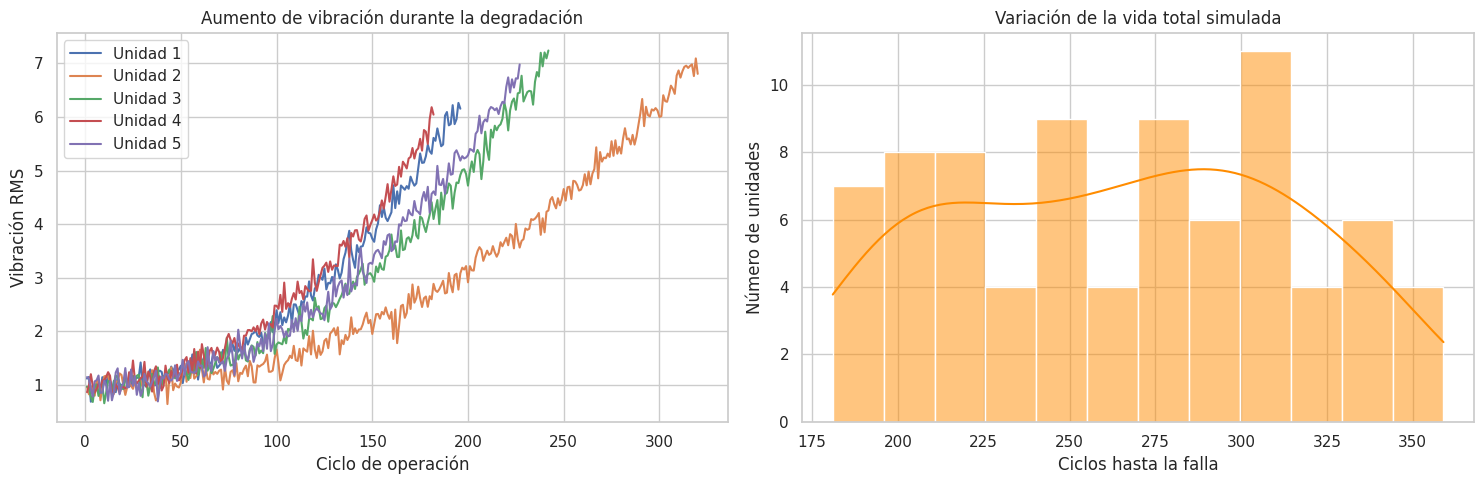

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for unidad in [1, 2, 3, 4, 5]:
    muestra = datos[datos["unidad"] == unidad]
    axes[0].plot(muestra["ciclo"], muestra["vibracion_rms"], label=f"Unidad {unidad}")
axes[0].set_title("Aumento de vibración durante la degradación")
axes[0].set_xlabel("Ciclo de operación")
axes[0].set_ylabel("Vibración RMS")
axes[0].legend()

sns.histplot(resumen_unidades["vida_total"], bins=12, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Variación de la vida total simulada")
axes[1].set_xlabel("Ciclos hasta la falla")
axes[1].set_ylabel("Número de unidades")
plt.tight_layout()
plt.show()

**Interpretación sencilla:** las curvas de vibración suben con el ciclo, aunque no lo hacen de forma perfectamente suave por el ruido de medición. Esa combinación de tendencia y variabilidad es típica de datos de sensores. La segunda gráfica muestra que algunos cojinetes duran más que otros; por eso no basta con usar una vida promedio.

## 6. Ingeniería de variables

Los sensores instantáneos son útiles, pero el estado de una máquina también está en su historia reciente. Por eso creamos, para cada unidad, un promedio móvil y una desviación estándar de 15 ciclos.

- `*_media_15`: nivel promedio reciente de la señal.
- `*_std_15`: variabilidad reciente de la señal.

El `shift(1)` es importante: evita usar el valor del ciclo actual para construir una ventana que supuestamente representa información previa.

### Explicación ampliada del ruido

En este contexto, **ruido** no significa necesariamente un sonido. Es una variación de la medición que no representa exactamente un cambio real en el cojinete.

Puede aparecer por vibraciones de otros componentes, cambios momentáneos de carga, temperatura ambiente, posición del sensor, interferencias eléctricas, comunicación, redondeo o limitaciones del instrumento. Por ejemplo, un termómetro puede mostrar pequeñas diferencias aunque la temperatura real casi no cambie.

El ruido no es lo mismo que una falla. El ruido suele ser pequeño, irregular y temporal. Una falla suele producir una tendencia persistente o un cambio que se repite. Por eso no conviene reaccionar ante una sola lectura.

La media móvil de 15 ciclos resume el comportamiento reciente y suaviza cambios aislados. La desviación estándar muestra qué tan variable ha sido la señal. Un promedio alto puede indicar un nivel preocupante; una desviación alta puede indicar inestabilidad.

Se agrega ruido a la simulación porque los datos perfectos serían poco realistas. El modelo debe aprender a distinguir entre variaciones normales y un deterioro sostenido. En la práctica, también conviene revisar la calidad del sensor antes de interpretar una señal como desgaste.


### Antes de ejecutar: crear variables históricas

Una lectura aislada puede ser engañosa. Por ejemplo, una vibración alta durante un instante puede deberse a una carga momentánea y no a una falla.

Por eso se calculan dos tipos de resumen para los 15 ciclos anteriores:

- `media_15`: nivel típico reciente.
- `std_15`: qué tanto ha variado la señal.

`groupby("unidad")` evita mezclar la historia de dos cojinetes. `shift(1)` mueve los datos una posición para que el ciclo actual no use su propio valor en la ventana histórica. `rolling(15)` forma la ventana móvil. Finalmente, `dropna()` elimina las primeras filas que todavía no tienen suficientes observaciones anteriores.

In [ ]:
sensores = ["vibracion_rms", "temperatura_c", "carga_pct", "ruido_acustico_db"]
ventana = 15

datos_modelo = datos.sort_values(["unidad", "ciclo"]).copy()
for sensor in sensores:
    grupo = datos_modelo.groupby("unidad")[sensor]
    datos_modelo[f"{sensor}_media_{ventana}"] = grupo.transform(
        lambda serie: serie.shift(1).rolling(ventana, min_periods=3).mean()
    )
    datos_modelo[f"{sensor}_std_{ventana}"] = grupo.transform(
        lambda serie: serie.shift(1).rolling(ventana, min_periods=3).std()
    )

# Las primeras filas de cada unidad no tienen una ventana completa; se eliminan.
datos_modelo = datos_modelo.dropna().reset_index(drop=True)
print(f"Filas disponibles para modelar: {len(datos_modelo):,}")
datos_modelo.head()

Filas disponibles para modelar: 20,962


,unidad,ciclo,vibracion_rms,temperatura_c,carga_pct,ruido_acustico_db,rul,vibracion_rms_media_15,vibracion_rms_std_15,temperatura_c_media_15,temperatura_c_std_15,carga_pct_media_15,carga_pct_std_15,ruido_acustico_db_media_15,ruido_acustico_db_std_15
0,1,4,0.792649,42.848903,61.073774,27.435319,192,0.986397,0.258557,42.034973,0.154512,61.292503,0.653184,28.103477,0.536229
1,1,5,1.022085,42.061563,61.776774,27.571258,191,0.937960,0.232276,42.238456,0.426071,61.237820,0.544420,27.936438,0.550730
2,1,6,0.951836,42.397134,59.713172,27.878504,190,0.954785,0.204645,42.203077,0.377373,61.345611,0.529518,27.863402,0.504132
3,1,7,1.000730,40.785016,60.814181,27.852579,189,0.954294,0.183044,42.235420,0.346706,61.073538,0.817591,27.865919,0.450951
4,1,8,0.868099,41.991052,61.644066,28.328060,188,0.960927,0.168015,42.028220,0.633005,61.036487,0.752765,27.864013,0.411691


## 7. Separación correcta entre entrenamiento y prueba

La separación se realiza por `unidad`, no por fila. Así el modelo se evalúa en cojinetes completos que nunca vio durante el entrenamiento. Este es uno de los principios más importantes del RUL: si mezclamos ciclos del mismo cojinete en ambos conjuntos, el resultado parecería mejor de lo que realmente es.

### Ejemplo sencillo

El entrenamiento es como estudiar con la historia completa de algunos cojinetes. La prueba consiste en usar la historia completa de otros cojinetes que el modelo nunca vio.

Si mezcláramos ciclos del mismo cojinete en ambos grupos, sería como mostrar parte de las respuestas antes de un examen. El resultado parecería muy bueno, pero no mediría la capacidad de trabajar con una unidad nueva.


### Antes de ejecutar: separar entrenamiento y prueba

`X` contiene las variables que el modelo usará como entrada. `y` contiene la RUL que queremos predecir. `grupos` identifica a qué cojinete pertenece cada fila.

`GroupShuffleSplit` separa por grupo. Esto es más correcto que separar filas al azar: si algunos ciclos de la misma unidad entraran al entrenamiento y otros a la prueba, el modelo podría reconocer indirectamente al componente y parecería más preciso de lo que sería en una unidad nueva.

La última comprobación confirma que no existen unidades compartidas entre ambos conjuntos.

In [ ]:
variables = [
    "ciclo", "vibracion_rms", "temperatura_c", "carga_pct", "ruido_acustico_db",
    "vibracion_rms_media_15", "vibracion_rms_std_15",
    "temperatura_c_media_15", "temperatura_c_std_15",
    "carga_pct_media_15", "carga_pct_std_15",
    "ruido_acustico_db_media_15", "ruido_acustico_db_std_15"
]
X = datos_modelo[variables]
y = datos_modelo["rul"]
grupos = datos_modelo["unidad"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
indices_train, indices_test = next(splitter.split(X, y, groups=grupos))

X_train, X_test = X.iloc[indices_train], X.iloc[indices_test]
y_train, y_test = y.iloc[indices_train], y.iloc[indices_test]

unidades_train = sorted(grupos.iloc[indices_train].unique())
unidades_test = sorted(grupos.iloc[indices_test].unique())
print(f"Unidades de entrenamiento: {len(unidades_train)}")
print(f"Unidades de prueba: {len(unidades_test)}")
print(f"¿Hay unidades compartidas?: {bool(set(unidades_train) & set(unidades_test))}")

Unidades de entrenamiento: 64
Unidades de prueba: 16
¿Hay unidades compartidas?: False


## 8. Modelos de referencia y modelo principal

Usaremos dos modelos:

1. **Regresión lineal**: sirve como referencia sencilla.
2. **HistGradientBoostingRegressor**: combina muchos árboles pequeños y aprende relaciones no lineales, por ejemplo, que una vibración moderada puede ser normal al principio pero preocupante cuando la temperatura y el ruido también aumentan.

La estandarización se aplica al modelo lineal. El modelo de árboles no la necesita, pero usarla en el modelo de referencia hace explícito el flujo de preparación.

### ¿Qué significa aprender?

Aprender significa ajustar una regla matemática usando ejemplos. La regresión lineal intenta representar la relación con una línea. El modelo de árboles es más flexible y puede reconocer reglas combinadas: por ejemplo, que una vibración moderada es normal al principio, pero preocupante cuando también aumenta la temperatura.

El modelo no recibe una explicación física automática. Por eso sus resultados deben revisarse junto con el conocimiento de mantenimiento.


### Antes de ejecutar: entrenar los modelos

Se comparan dos modelos para tener un punto de referencia.

- `LinearRegression` supone una relación aproximadamente lineal. Es sencillo y ayuda a saber si un modelo más complejo realmente aporta valor.
- `HistGradientBoostingRegressor` combina muchos árboles pequeños. Cada árbol intenta corregir errores del anterior, por lo que puede aprender relaciones curvas y combinaciones entre sensores.

`fit` significa entrenar: el modelo busca patrones usando `X_train` y `y_train`. `predict` genera estimaciones para datos que no se usaron para entrenar.

`np.clip(..., 0, None)` evita predicciones negativas. Una RUL menor que cero no tiene sentido físico en este ejemplo, aunque una predicción negativa también puede ser una señal de que el modelo necesita mejora.

In [ ]:
modelo_lineal = make_pipeline(StandardScaler(), LinearRegression())
modelo_arboles = HistGradientBoostingRegressor(
    max_iter=250,
    learning_rate=0.06,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=SEED
)

modelo_lineal.fit(X_train, y_train)
modelo_arboles.fit(X_train, y_train)

pred_lineal = np.clip(modelo_lineal.predict(X_test), 0, None)
pred_arboles = np.clip(modelo_arboles.predict(X_test), 0, None)

def evaluar(nombre, real, prediccion):
    return {
        "modelo": nombre,
        "MAE_ciclos": mean_absolute_error(real, prediccion),
        "RMSE_ciclos": mean_squared_error(real, prediccion) ** 0.5,
        "R2": r2_score(real, prediccion)
    }

metricas = pd.DataFrame([
    evaluar("Regresión lineal", y_test, pred_lineal),
    evaluar("HistGradientBoosting", y_test, pred_arboles)
]).sort_values("MAE_ciclos")
metricas.round(2)

,modelo,MAE_ciclos,RMSE_ciclos,R2
1,HistGradientBoosting,17.13,25.66,0.89
0,Regresión lineal,27.70,36.60,0.78


### Cómo leer las métricas

- **MAE**: error absoluto medio. Si vale 12, el modelo se equivoca en promedio por aproximadamente 12 ciclos.
- **RMSE**: penaliza más los errores grandes; ayuda a detectar predicciones muy alejadas.
- **R²**: indica qué tanta variación explica el modelo. Un valor cercano a 1 es mejor, aunque no sustituye al MAE.

Para mantenimiento, el MAE suele ser fácil de comunicar: “la estimación tiene un error promedio de aproximadamente X ciclos”.

### Ejemplo de las métricas

Si el MAE es 12 ciclos, las predicciones se separan del valor real aproximadamente 12 ciclos en promedio. No significa que todas fallen por exactamente 12.

El RMSE da más peso a los errores grandes. El R² resume qué tan bien sigue el modelo la variación de los datos. Para mantenimiento, el MAE suele ser el más fácil de comunicar porque está expresado en ciclos.


## 9. Visualización de predicciones

La primera gráfica compara RUL real contra RUL predicha. Si el modelo fuera perfecto, todos los puntos quedarían sobre la diagonal. La segunda muestra el error según el RUL real; permite revisar si el modelo se comporta peor cuando la falla está cerca.

### ¿Por qué mirar las gráficas?

Una métrica resume el resultado en un número, pero la gráfica muestra cómo se comporta. Los puntos cercanos a la diagonal indican mejores estimaciones.

También importa el tipo de error: estimar poca vida puede provocar un cambio anticipado; estimar demasiada vida puede retrasar una inspección. La decisión depende de la criticidad del equipo y del costo de cada error.


### Antes de ejecutar: entender las métricas

La función `evaluar` compara la RUL real contra la predicha.

- `MAE` calcula el error absoluto promedio. Es la métrica más sencilla de explicar: cuántos ciclos se desvía el modelo, en promedio.
- `RMSE` castiga con más fuerza los errores grandes. Sirve para detectar si hay predicciones muy alejadas.
- `R2` indica qué proporción de la variación de la RUL logra explicar el modelo. Debe revisarse junto con MAE y RMSE, no de manera aislada.

La tabla final ordena los modelos por MAE, colocando primero el que tiene menor error promedio.

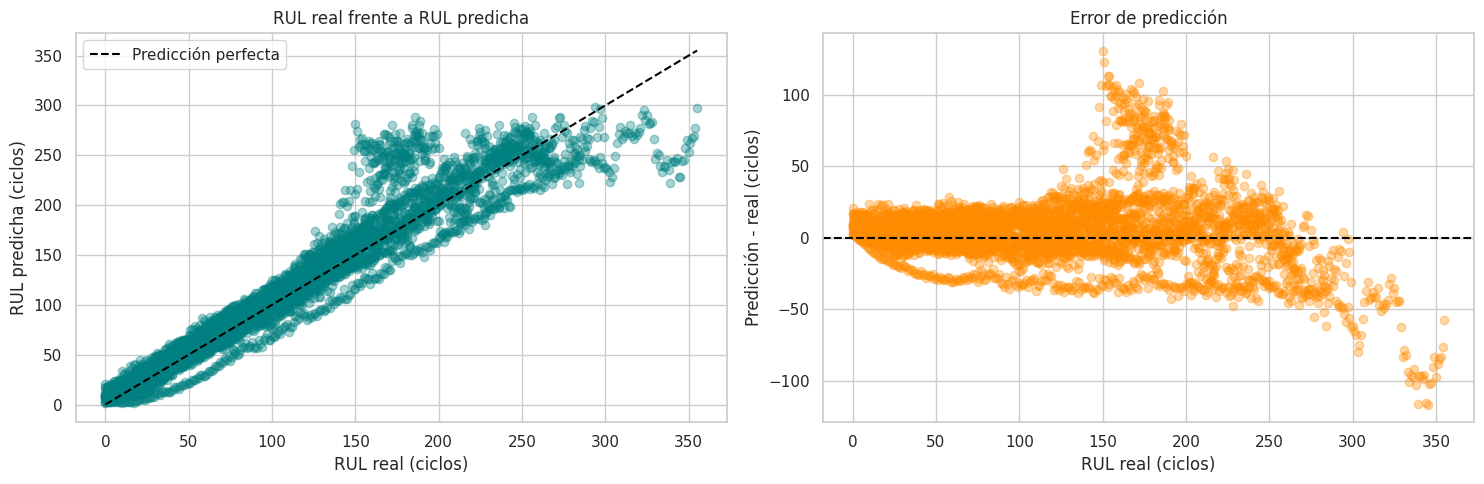

Error medio absoluto del modelo principal: 17.1 ciclos


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test, pred_arboles, alpha=0.35, color="teal")
limite = max(y_test.max(), pred_arboles.max())
axes[0].plot([0, limite], [0, limite], "--", color="black", label="Predicción perfecta")
axes[0].set_title("RUL real frente a RUL predicha")
axes[0].set_xlabel("RUL real (ciclos)")
axes[0].set_ylabel("RUL predicha (ciclos)")
axes[0].legend()

error = pred_arboles - y_test.to_numpy()
axes[1].scatter(y_test, error, alpha=0.35, color="darkorange")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Error de predicción")
axes[1].set_xlabel("RUL real (ciclos)")
axes[1].set_ylabel("Predicción - real (ciclos)")
plt.tight_layout()
plt.show()

print(f"Error medio absoluto del modelo principal: {mean_absolute_error(y_test, pred_arboles):.1f} ciclos")

**Interpretación:** los puntos cercanos a la diagonal indican buenas estimaciones. Si hay puntos muy alejados, representan momentos en los que el modelo podría hacer que mantenimiento intervenga demasiado pronto o demasiado tarde. En la gráfica de errores, una nube centrada alrededor de cero es deseable; una forma inclinada o un patrón curvo puede indicar sesgo o que faltan variables.

## 10. Seguimiento de una unidad de prueba

Ahora elegimos una unidad que el modelo no vio durante el entrenamiento y mostramos cómo cambia la predicción a través de su vida. Esto se parece más al uso real: conforme llegan nuevos ciclos de sensores, se actualiza la estimación de vida restante.

### Cómo se usaría en mantenimiento

Cada vez que llegan nuevas mediciones, el sistema puede actualizar la estimación. La RUL debe generar una alerta o apoyar una inspección, no sustituir automáticamente los límites de seguridad ni el criterio del personal responsable.


### Antes de ejecutar: interpretar las gráficas de predicción

En la gráfica izquierda, cada punto representa una observación de prueba. El eje horizontal es la RUL real y el eje vertical es la RUL predicha.

- Sobre la diagonal: predicción perfecta.
- Debajo de la diagonal: el modelo estima menos vida de la que realmente quedaba.
- Encima de la diagonal: el modelo estima más vida de la que realmente quedaba; esto puede ser más riesgoso si retrasa una intervención.

La gráfica derecha muestra el error. Una nube alrededor de cero es mejor que una nube desplazada o con una forma curva. Un patrón puede revelar que el modelo funciona bien en unas etapas de la vida, pero mal en otras.

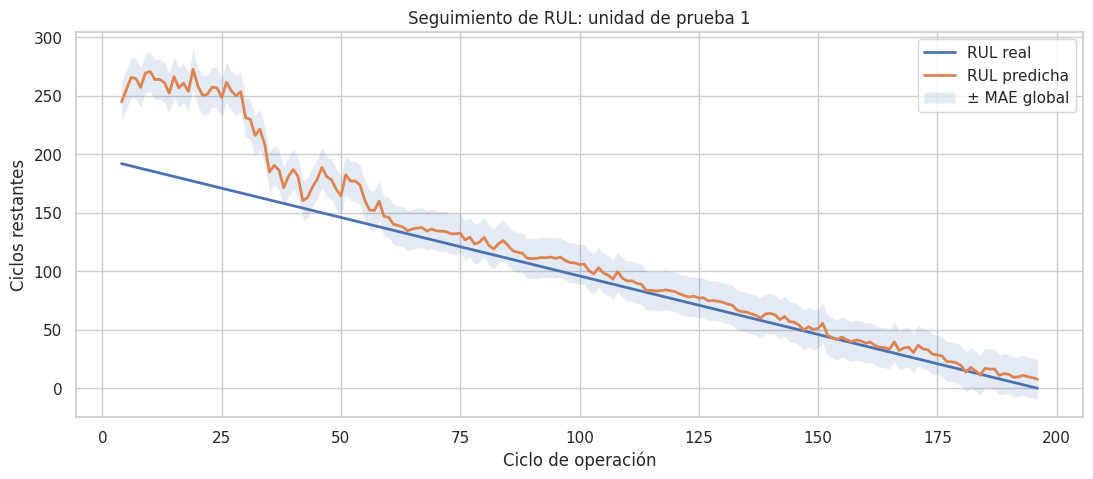

Vida real registrada de la unidad: 196 ciclos
Última predicción disponible: 7.7 ciclos restantes


In [ ]:
unidad_ejemplo = unidades_test[0]
serie = datos_modelo[datos_modelo["unidad"] == unidad_ejemplo].copy()
serie["rul_predicha"] = np.clip(modelo_arboles.predict(serie[variables]), 0, None)

plt.figure(figsize=(13, 5))
plt.plot(serie["ciclo"], serie["rul"], label="RUL real", linewidth=2)
plt.plot(serie["ciclo"], serie["rul_predicha"], label="RUL predicha", linewidth=2)
plt.fill_between(
    serie["ciclo"], serie["rul_predicha"] - metricas.loc[metricas["modelo"] == "HistGradientBoosting", "MAE_ciclos"].iloc[0],
    serie["rul_predicha"] + metricas.loc[metricas["modelo"] == "HistGradientBoosting", "MAE_ciclos"].iloc[0],
    alpha=0.15, label="± MAE global"
)
plt.title(f"Seguimiento de RUL: unidad de prueba {unidad_ejemplo}")
plt.xlabel("Ciclo de operación")
plt.ylabel("Ciclos restantes")
plt.legend()
plt.show()

print(f"Vida real registrada de la unidad: {serie['ciclo'].max()} ciclos")
print(f"Última predicción disponible: {serie['rul_predicha'].iloc[-1]:.1f} ciclos restantes")

**Interpretación sencilla:** al avanzar los ciclos, la RUL real baja hacia cero. Una predicción útil debería seguir esa tendencia. En una máquina real, esta curva podría alimentar una regla de decisión, por ejemplo: inspeccionar cuando la RUL estimada sea menor a 40 ciclos, siempre validando primero el umbral con expertos y costos reales.

## 11. ¿Qué sensores influyen más?

La importancia por permutación mide cuánto empeora el error cuando se desordena una variable. Si el error sube mucho, esa variable estaba aportando información útil. Esto ayuda a explicar el modelo, aunque no demuestra causalidad física.

### Qué significa y qué no significa la importancia

Si la vibración es importante, significa que el modelo la usa para mejorar sus predicciones. No demuestra por sí sola que sea la causa física de la falla. Dos sensores pueden contener información parecida, por lo que uno puede parecer menos importante aunque siga siendo útil.

Esta revisión ayuda a formular preguntas: ¿el sensor está bien instalado?, ¿la señal tiene suficiente calidad?, ¿faltan variables como velocidad, lubricación o carga?


### Antes de ejecutar: seguir una unidad concreta

Aquí se selecciona una unidad del conjunto de prueba. El modelo nunca la utilizó para aprender.

La predicción se calcula ciclo por ciclo y se grafica junto con la RUL real. Esto permite ver algo que una sola métrica no muestra: si el modelo sigue correctamente la tendencia de disminución de vida.

La banda alrededor de la predicción usa el MAE global como referencia visual. No es un intervalo estadístico formal de confianza; solo ayuda a visualizar el tamaño típico del error.

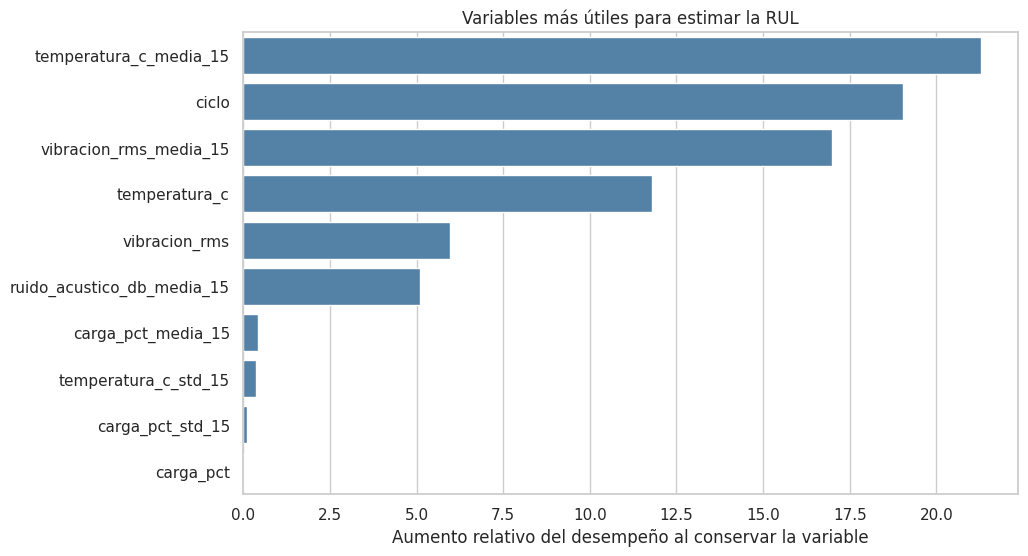

,variable,importancia_media,variacion
7,temperatura_c_media_15,21.2931,0.2318
0,ciclo,19.0476,0.4626
5,vibracion_rms_media_15,16.9879,0.2658
2,temperatura_c,11.8051,0.1685
1,vibracion_rms,5.9751,0.0243
11,ruido_acustico_db_media_15,5.0957,0.1667
9,carga_pct_media_15,0.4175,0.0729
8,temperatura_c_std_15,0.3771,0.0205
10,carga_pct_std_15,0.1135,0.0574
3,carga_pct,0.0291,0.0076


In [ ]:
X_importancia = X_test.sample(min(1000, len(X_test)), random_state=SEED)
y_importancia = y_test.loc[X_importancia.index]
importancias = permutation_importance(
    modelo_arboles, X_importancia, y_importancia, n_repeats=3, random_state=SEED, scoring="neg_mean_absolute_error"
)

importancias_df = pd.DataFrame({
    "variable": variables,
    "importancia_media": importancias.importances_mean,
    "variacion": importancias.importances_std
}).sort_values("importancia_media", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importancias_df.head(10), x="importancia_media", y="variable", color="steelblue")
plt.title("Variables más útiles para estimar la RUL")
plt.xlabel("Aumento relativo del desempeño al conservar la variable")
plt.ylabel("")
plt.show()

importancias_df.head(10).round(4)

**Interpretación:** normalmente esperamos que el ciclo actual, la vibración y la temperatura estén entre las variables relevantes porque reflejan progreso de desgaste. Si una variable aparece como poco importante, no significa automáticamente que sea inútil: puede ser redundante con otra, tener mucho ruido o necesitar una transformación física más adecuada.

## 12. Conclusiones generales

1. RUL convierte la historia de sensores en una estimación de ciclos restantes, lo que permite planear mantenimiento antes de una falla inesperada.
2. La separación por componente es fundamental; mezclar ciclos del mismo equipo entre entrenamiento y prueba puede inflar artificialmente el desempeño.
3. Las variables históricas —promedios y variabilidad recientes— suelen ser más informativas que una lectura aislada.
4. El MAE ofrece una forma sencilla de comunicar el resultado: el error promedio está expresado en ciclos.
5. La predicción no debe tratarse como una fecha exacta de falla. Debe combinarse con inspecciones, límites de seguridad, criticidad del activo y costo de intervención.
6. Este ejemplo es un punto de partida. Para pasar a producción habría que validar con datos reales, hacer pruebas temporales, cuantificar incertidumbre, tratar unidades que aún no fallan y monitorear el desempeño después del despliegue.

### Siguientes pasos de I+D

- Sustituir los datos simulados por históricos reales de sensores.
- Comparar modelos de árboles con LSTM o Transformers temporales cuando haya muchas series y suficiente volumen de datos.
- Incorporar intervalos de predicción, no solo un número puntual.
- Traducir la RUL a una política de mantenimiento y medir reducción de paros, costo y falsas alarmas.
- Evaluar el modelo por unidad, por régimen de carga y por horizonte de anticipación.